# Maintenance prédictive — Baseline de classification

## Objectif concret

Ce notebook réalise le TP B5 complet : préparation du Gold dataset, gestion du déséquilibre, entraînement d'une régression logistique, choix du seuil sur la validation et évaluation finale sur le test.

Le problème est une **classification binaire supervisée**. *Supervisée* signifie que les exemples historiques possèdent déjà la réponse attendue ; *binaire* signifie que cette réponse ne prend que deux classes : panne (`1`) ou absence de panne (`0`). Le **Gold dataset** est la table analytique préparée pour le modèle : elle rassemble, à un grain défini, les variables calculées depuis les données nettoyées et les cibles historiques.

Une **feature**, appelée **variable explicative** dans le cours, est une information fournie au modèle. La **cible**, souvent nommée `y`, est la réponse que le modèle doit apprendre à prédire. Une **fuite de données** apparaît lorsqu'une variable explicative contient une information future qui ne serait pas connue au moment réel de la prédiction.

Dans le CSV, `window_start` ouvre la fenêtre de variables explicatives et `window_end` correspond à l'instant où elles sont disponibles : `window_end` est donc l'ancre de prédiction. La cellule suivante doit être exécutée depuis la racine du projet `indusense`. Elle charge le CSV Gold, convertit les bornes temporelles en dates, trie les lignes par machine puis par ancre et affiche le point de départ observable.

### Vocabulaire à employer pendant le TP

Dans le vocabulaire du cours, une ligne est une **observation** : ici, l'état d'une machine à une heure donnée. Les *features* sont les **variables explicatives** observables à l'ancre de prédiction ; la colonne `label_failure_next_24h` est la **variable cible**. Le modèle produit d'abord un **score de risque** ; une décision d'alerte n'apparaît qu'après application d'un seuil. Comme le modèle est entraîné avec `class_weight='balanced'`, ce score sert à classer les risques, mais ne doit pas être annoncé sans réserve comme une probabilité parfaitement calibrée.

**À vérifier après la cellule 1.** Le tableau doit afficher le fichier Gold, son nombre de lignes et de machines, une durée de fenêtre de `1 heure` et `0` doublon pour le couple `(machine_id_std, window_end)`. Si une assertion échoue, il faut corriger le dossier de lancement ou la structure du fichier avant de poursuivre : les étapes suivantes supposent ce grain de données.

## Fil conducteur du notebook

Le raisonnement suit l'ordre réel d'un projet de Machine Learning supervisé :

1. comprendre ce que représente une ligne ;
2. définir la cible et séparer passé, validation et futur ;
3. retirer les informations indisponibles au moment de prédire ;
4. mesurer le déséquilibre entre pannes et non-pannes ;
5. entraîner une baseline sur le train seulement ;
6. évaluer la capacité à classer les risques ;
7. choisir un seuil de décision sur la validation ;
8. mesurer une fois la performance finale sur le test ;
9. interpréter prudemment le modèle et ses limites.

## Références pédagogiques

- [Support AELION — Évaluation des modèles](../../../../docs/02-sprint-2/01-cours/06_Evaluation_AELION.pdf) : séparation entraînement/test, matrice de confusion, précision, rappel et ROC-AUC.
- [Cours structuré — Évaluation des modèles](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md) : définitions, formules, démarche et erreurs fréquentes.
- [Fiche — Classification binaire et découpage temporel](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md) : application directe au cas Indusense.
- [Transcription complète du cours](../../../../docs/02-sprint-2/02-transcriptions/03-jour-2-evaluation-des-modeles.txt) : contenu oral horodaté et complément du support.

In [1]:
from pathlib import Path

import pandas as pd
from tabulate import tabulate

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'datas' / 'gold_dataset_20260622-080603.csv'

assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)
assert DATA_PATH.exists(), f'Fichier Gold introuvable : {DATA_PATH}'

# Les dates sont converties dès la lecture afin de permettre les contrôles chronologiques.
gold = pd.read_csv(
    DATA_PATH,
    parse_dates=['window_start', 'window_end'],
)
PREDICTION_TIME_COLUMN = 'window_end'
gold = gold.sort_values(
    ['machine_id_std', PREDICTION_TIME_COLUMN],
    kind='stable',
).reset_index(drop=True)

# Une ligne doit représenter un seul instant de prédiction pour une seule machine.
grain_columns = ['machine_id_std', PREDICTION_TIME_COLUMN]
duplicate_grain_count = int(gold.duplicated(grain_columns).sum())
assert duplicate_grain_count == 0, (
    f'{duplicate_grain_count} doublons détectés sur le grain {grain_columns}.'
)

window_durations = gold['window_end'] - gold['window_start']
assert window_durations.eq(pd.Timedelta(hours=1)).all(), (
    'Chaque fenêtre Gold doit couvrir exactement une heure.'
)

dataset_summary = [
    ['Fichier chargé', DATA_PATH.name],
    ['Nombre de lignes', f'{len(gold):,}'.replace(',', ' ')],
    ['Nombre de colonnes', gold.shape[1]],
    ['Nombre de machines', gold['machine_id_std'].nunique()],
    ['Première ancre', gold[PREDICTION_TIME_COLUMN].min()],
    ['Dernière ancre', gold[PREDICTION_TIME_COLUMN].max()],
    ['Durée de chaque fenêtre', '1 heure'],
    ['Doublons machine + ancre', duplicate_grain_count],
]

print(tabulate(dataset_summary, headers=['Contrôle', 'Résultat'], tablefmt='github'))

| Contrôle                 | Résultat                         |
|--------------------------|----------------------------------|
| Fichier chargé           | gold_dataset_20260622-080603.csv |
| Nombre de lignes         | 134 280                          |
| Nombre de colonnes       | 100                              |
| Nombre de machines       | 15                               |
| Première ancre           | 2025-06-01 01:00:00              |
| Dernière ancre           | 2026-06-09 00:00:00              |
| Durée de chaque fenêtre  | 1 heure                          |
| Doublons machine + ancre | 0                                |


## Lecture du résultat précédent : quel dataset avons-nous ?

Le Gold dataset contient **134 280 observations**, **100 colonnes** et **15 machines** entre le 1er juin 2025 et le 9 juin 2026. Une observation correspond à une machine et à une ancre horaire ; ce n'est donc pas une panne individuelle, mais un état calculé à partir d'une fenêtre d'une heure. Les `0` doublons confirment que chaque couple `(machine, ancre)` apparaît une seule fois : le **grain** annoncé est respecté. Le grain est l'unité exacte représentée par une ligne.

Ce contrôle ne dit encore rien sur la capacité à prédire. Il établit seulement que les données ont la structure attendue. Les fenêtres successives d'une même machine restent proches dans le temps et peuvent partager de l'information : les 134 280 lignes ne doivent donc pas être interprétées comme autant d'événements totalement indépendants.

## Choisir la cible et vérifier le découpage temporel

L'**horizon de prédiction** est la durée future couverte par la question métier. Nous retenons `label_failure_next_24h` : `1` signifie qu'une panne est observée dans les 24 heures suivantes, `0` signifie qu'aucune panne n'y est observée.

Le fichier fournit trois jeux dans `split_set`. Le jeu d'**entraînement** ajuste le futur modèle ; la **validation** sert à comparer des choix et à fixer le seuil ; le **test** reste à l'écart jusqu'à l'évaluation finale. La cellule suivante vérifie que ces périodes ne se chevauchent pas et mesure le taux de positifs dans chacune.

### Pourquoi cet ordre est indispensable

Le découpage est **chronologique** : le train est le passé connu, la validation une période plus récente sur laquelle on prend les décisions de modélisation, puis le test représente une période future non consultée. Un découpage aléatoire mélangerait potentiellement des observations voisines dans le passé et le futur ; il donnerait une estimation trop optimiste de la généralisation. La validation n'est donc pas un second entraînement, et le test n'est pas un espace d'essais supplémentaire.

**À vérifier après la cellule 3.** Le tableau doit présenter les trois jeux dans l'ordre `train`, `validation`, `test`, avec une dernière ancre du train strictement antérieure à la première ancre de validation, puis le même ordre entre validation et test. Le taux de panne est la **prévalence** de la classe positive ; il servira de repère pour interpréter la PR-AUC.

In [2]:
TARGET_COLUMN = 'label_failure_next_24h'
SPLIT_COLUMN = 'split_set'
EXPECTED_SPLITS = ['train', 'validation', 'test']

required_columns = {
    'machine_id_std', 'window_start', PREDICTION_TIME_COLUMN, TARGET_COLUMN, SPLIT_COLUMN
}
missing_required_columns = sorted(required_columns.difference(gold.columns))
assert not missing_required_columns, (
    f'Colonnes obligatoires absentes : {missing_required_columns}'
)

observed_splits = gold[SPLIT_COLUMN].dropna().unique().tolist()
assert observed_splits == EXPECTED_SPLITS, (
    f'Ordre des splits inattendu : {observed_splits}'
)
assert set(gold[TARGET_COLUMN].dropna().unique()).issubset({False, True, 0, 1}), (
    f'La cible {TARGET_COLUMN} doit être binaire.'
)
assert not gold[TARGET_COLUMN].isna().any(), 'La cible contient des valeurs manquantes.'

split_rows = []
for split_name in EXPECTED_SPLITS:
    split_data = gold.loc[gold[SPLIT_COLUMN].eq(split_name)]
    split_rows.append([
        split_name,
        len(split_data),
        split_data[PREDICTION_TIME_COLUMN].min(),
        split_data[PREDICTION_TIME_COLUMN].max(),
        int(split_data[TARGET_COLUMN].sum()),
        f"{split_data[TARGET_COLUMN].mean():.2%}",
    ])

split_periods = {row[0]: (row[2], row[3]) for row in split_rows}
assert split_periods['train'][1] < split_periods['validation'][0]
assert split_periods['validation'][1] < split_periods['test'][0]

print(tabulate(
    split_rows,
    headers=['Jeu', 'Lignes', 'Première ancre', 'Dernière ancre', 'Positifs', 'Taux positif'],
    tablefmt='github',
))

| Jeu        |   Lignes | Première ancre      | Dernière ancre      |   Positifs | Taux positif   |
|------------|----------|---------------------|---------------------|------------|----------------|
| train      |    93990 | 2025-06-01 01:00:00 | 2026-02-17 02:00:00 |      15598 | 16.60%         |
| validation |    20145 | 2026-02-17 03:00:00 | 2026-04-14 01:00:00 |       3472 | 17.24%         |
| test       |    20145 | 2026-04-14 02:00:00 | 2026-06-09 00:00:00 |       3478 | 17.26%         |


## Lecture du résultat précédent : les périodes sont-elles bien séparées ?

Le train contient **93 990 lignes**, puis la validation et le test **20 145 lignes chacun**. Les bornes s'enchaînent sans chevauchement : le train s'arrête le 17 février 2026 à 02 h, la validation commence à 03 h ; elle s'arrête le 14 avril à 01 h et le test commence à 02 h. Cela confirme un protocole passé → futur cohérent avec l'usage réel.

La prévalence passe de **16,60 %** sur le train à **17,24 %** sur la validation et **17,26 %** sur le test. Ces taux proches indiquent que la fréquence globale des pannes reste relativement stable entre les trois périodes. Cela ne prouve toutefois pas que les relations entre capteurs et pannes sont identiques : un changement de comportement des variables peut exister même avec une prévalence stable.

**Conclusion de l'étape :** les rôles sont séparés correctement. Le train servira au `fit`, la validation aux choix, et le test à la mesure finale. Voir [la section sur les trois jeux](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#2-séparer-entraînement-validation-et-test).

## Séparer les features et la cible sans fuite

Les colonnes `future_incident_count_*` décrivent directement le futur : elles doivent être exclues. Les autres `label_failure_next_*` sont également des cibles futures et ne peuvent pas devenir des features.

L'identifiant de machine, les deux timestamps bruts et `split_set` sont conservés pour la traçabilité et les contrôles, mais pas fournis à cette première baseline. Une **baseline** est un premier modèle simple qui sert de référence.

La cellule suivante construit la liste des features autorisées, crée les matrices `X` et les cibles `y` pour chaque période, puis vérifie leurs dimensions. Elle ne réalise encore ni imputation, ni standardisation, ni entraînement.

### Règle de disponibilité à l'instant de prédiction

Pour décider à `window_end`, chaque variable explicative doit être connue au plus tard à `window_end`. Une colonne `future_incident_count_*` ou un autre `label_failure_next_*` décrit une conséquence future : l'utiliser rendrait la prédiction artificiellement facile et créerait une **fuite de données**. Les identifiants, les dates brutes et `split_set` sont retirés de cette baseline afin que le modèle n'apprenne pas un raccourci lié à la machine ou à la période plutôt qu'un signal de maintenance.

`X_train`, `X_validation` et `X_test` sont les **matrices de variables explicatives** ; `y_train`, `y_validation` et `y_test` sont les **vecteurs de cible** correspondants. **À vérifier après la cellule 5 :** les trois assertions confirment l'absence de labels futurs et de comptes futurs dans les features, et les tableaux doivent montrer le même nombre de colonnes pour les trois jeux.

In [3]:
label_columns = [column for column in gold.columns if column.startswith('label_failure_next_')]
future_information_columns = [
    column for column in gold.columns if column.startswith('future_incident_count_')
]
identifier_columns = ['machine_id_std']
raw_time_columns = ['window_start', 'window_end']
control_columns = [SPLIT_COLUMN]

excluded_columns = list(dict.fromkeys(
    identifier_columns
    + raw_time_columns
    + control_columns
    + label_columns
    + future_information_columns
))
feature_columns = [column for column in gold.columns if column not in excluded_columns]

# Cette baseline accepte uniquement des variables numériques ou booléennes.
non_numeric_features = gold[feature_columns].select_dtypes(
    exclude=['number', 'bool'],
).columns.tolist()
assert TARGET_COLUMN not in feature_columns
assert not set(future_information_columns).intersection(feature_columns)
assert not set(label_columns).intersection(feature_columns)
assert not non_numeric_features, f'Features non numériques : {non_numeric_features}'

def extract_split(split_name):
    mask = gold[SPLIT_COLUMN].eq(split_name)
    X = gold.loc[mask, feature_columns].copy()
    y = gold.loc[mask, TARGET_COLUMN].astype('int8').copy()
    assert len(X) == len(y)
    assert X.index.equals(y.index)
    return X, y

X_train, y_train = extract_split('train')
X_validation, y_validation = extract_split('validation')
X_test, y_test = extract_split('test')

exclusion_summary = [
    ['Identifiants', len(identifier_columns), ', '.join(identifier_columns)],
    ['Temps bruts', len(raw_time_columns), ', '.join(raw_time_columns)],
    ['Contrôle du split', len(control_columns), ', '.join(control_columns)],
    ['Labels futurs', len(label_columns), ', '.join(label_columns)],
    ['Comptages futurs', len(future_information_columns), ', '.join(future_information_columns)],
]
split_shape_summary = [
    ['train', X_train.shape[0], X_train.shape[1], int(y_train.sum()), int(X_train.isna().sum().sum())],
    ['validation', X_validation.shape[0], X_validation.shape[1], int(y_validation.sum()), int(X_validation.isna().sum().sum())],
    ['test', X_test.shape[0], X_test.shape[1], int(y_test.sum()), int(X_test.isna().sum().sum())],
]

print('Politique d’exclusion :')
print(tabulate(
    exclusion_summary,
    headers=['Famille', 'Nombre', 'Colonnes'],
    tablefmt='github',
))
print(f'\nFeatures retenues : {len(feature_columns)}')
print(f'Premières features : {feature_columns[:8]}')
print('\nJeux prêts pour la prochaine partie :')
print(tabulate(
    split_shape_summary,
    headers=['Jeu', 'Lignes X', 'Colonnes X', 'Positifs y', 'NaN dans X'],
    tablefmt='github',
))
print('\nPARTIE_1_VALIDEE : données séparées sans imputation, standardisation ni modèle.')

Politique d’exclusion :
| Famille           |   Nombre | Colonnes                                                                                                  |
|-------------------|----------|-----------------------------------------------------------------------------------------------------------|
| Identifiants      |        1 | machine_id_std                                                                                            |
| Temps bruts       |        2 | window_start, window_end                                                                                  |
| Contrôle du split |        1 | split_set                                                                                                 |
| Labels futurs     |        4 | label_failure_next_6h, label_failure_next_12h, label_failure_next_24h, label_failure_next_48h             |
| Comptages futurs  |        4 | future_incident_count_6h, future_incident_count_12h, future_incident_count_24h, future_incident_c

## Lecture du résultat précédent : que donnera-t-on réellement au modèle ?

Sur les **100 colonnes** initiales, 12 sont exclues du modèle : 1 identifiant, 2 timestamps, 1 colonne de contrôle, 4 labels futurs et 4 comptages futurs. Il reste **88 variables explicatives**. Cette exclusion est une décision de protocole, pas un nettoyage arbitraire : elle empêche le modèle d'utiliser la réponse attendue ou une information postérieure à `window_end`.

Les matrices contiennent encore des valeurs manquantes : **185 053** dans le train, **37 875** dans la validation et **37 739** dans le test. Rapporté au nombre total de cases, cela représente environ **2,24 %**, **2,14 %** et **2,13 %**. Aucune ligne n'est supprimée ici ; l'imputation sera apprise plus tard dans le Pipeline, uniquement sur le train.

Le marqueur `PARTIE_1_VALIDEE` signifie que la séparation `X/y` est techniquement cohérente. Il ne signifie pas encore qu'un modèle a été entraîné ni qu'il est performant. Voir [la démarche Indusense sans fuite](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md#démarche-pour-indusense).

## Mesurer et traiter le déséquilibre des classes

Une classe est **minoritaire** lorsqu'elle contient nettement moins d'exemples que l'autre. Ici, les pannes sont moins fréquentes que les non-pannes. Une prédiction toujours égale à `0` obtiendrait donc une accuracy élevée sans détecter la moindre panne. L'**accuracy** est la proportion totale de prédictions correctes ; elle ne sera pas notre métrique principale.

La régression logistique utilisera `class_weight='balanced'`. Scikit-learn donnera automatiquement plus de poids aux erreurs commises sur la classe minoritaire, avec des poids calculés uniquement à partir du jeu d'entraînement. `scale_pos_weight` répond au même besoin pour XGBoost, mais aucun modèle XGBoost n'est entraîné dans ce TP.

La cellule suivante calcule la répartition des classes dans chaque période, les poids théoriques du train et l'accuracy trompeuse d'une règle qui prédirait toujours l'absence de panne.

### Lire le déséquilibre avec les mots du cours

La classe `1` est la **classe positive** : une panne dans l'horizon de 24 heures. La classe `0` est la **classe négative** : pas de panne dans cet horizon. L'accuracy vaut `(TP + TN) / (TP + TN + FP + FN)` ; elle peut être élevée simplement parce que les non-pannes sont nombreuses. Une règle « toujours 0 » a en revanche un **rappel** de 0 : elle ne détecte aucune panne.

`class_weight='balanced'` ne fabrique pas de pannes et ne change pas les données. Pendant l'ajustement, il donne plus de poids à l'erreur sur une panne pour que le modèle ne privilégie pas mécaniquement la classe majoritaire. **À vérifier après la cellule 7 :** la barre des pannes doit être minoritaire dans les trois jeux et l'accuracy de la règle toujours `0` doit être lue comme une référence trompeuse, non comme une performance acceptable.

| Jeu        |   Non-pannes |   Pannes | Taux de panne   | Accuracy toujours 0   |
|------------|--------------|----------|-----------------|-----------------------|
| train      |        78392 |    15598 | 16.60%          | 83.40%                |
| validation |        16673 |     3472 | 17.24%          | 82.76%                |
| test       |        16667 |     3478 | 17.26%          | 82.74%                |

Poids théoriques du train : classe 0 = 0.599, classe 1 = 3.013
Une règle toujours égale à 0 atteindrait 83.40% d'accuracy sur le train, avec 0 % de rappel.


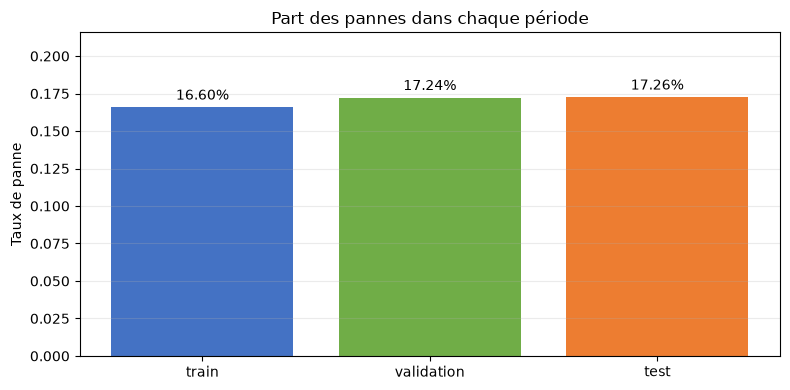

In [4]:
import matplotlib.pyplot as plt
import numpy as np

targets_by_split = {
    'train': y_train,
    'validation': y_validation,
    'test': y_test,
}
class_rows = []
for split_name, target in targets_by_split.items():
    negative_count = int(target.eq(0).sum())
    positive_count = int(target.eq(1).sum())
    class_rows.append([
        split_name,
        negative_count,
        positive_count,
        f'{positive_count / len(target):.2%}',
        f'{negative_count / len(target):.2%}',
    ])

train_negative_count = int(y_train.eq(0).sum())
train_positive_count = int(y_train.eq(1).sum())
balanced_weights = {
    0: len(y_train) / (2 * train_negative_count),
    1: len(y_train) / (2 * train_positive_count),
}
majority_accuracy = train_negative_count / len(y_train)

print(tabulate(
    class_rows,
    headers=['Jeu', 'Non-pannes', 'Pannes', 'Taux de panne', 'Accuracy toujours 0'],
    tablefmt='github',
))
print(f"\nPoids théoriques du train : classe 0 = {balanced_weights[0]:.3f}, classe 1 = {balanced_weights[1]:.3f}")
print(f"Une règle toujours égale à 0 atteindrait {majority_accuracy:.2%} d'accuracy sur le train, avec 0 % de rappel.")

positive_rates = [target.mean() for target in targets_by_split.values()]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(targets_by_split.keys(), positive_rates, color=['#4472C4', '#70AD47', '#ED7D31'])
ax.bar_label(bars, labels=[f'{rate:.2%}' for rate in positive_rates], padding=3)
ax.set_title('Part des pannes dans chaque période')
ax.set_ylabel('Taux de panne')
ax.set_ylim(0, max(positive_rates) * 1.25)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : pourquoi l'accuracy nous tromperait-elle ?

Dans le train, on observe **15 598 pannes** contre **78 392 non-pannes**. Une règle qui répond toujours « pas de panne » aurait donc **83,40 % d'accuracy**, alors qu'elle manquerait les 15 598 pannes : son rappel serait de **0 %**. Ce résultat illustre pourquoi une valeur élevée n'est utile que si la métrique correspond au besoin métier.

Le poids théorique de la classe positive vaut **3,013**, contre **0,599** pour la classe négative. Une erreur sur une panne pèsera donc environ cinq fois plus qu'une erreur sur une non-panne pendant l'entraînement. Cela pousse le modèle à prêter attention aux pannes rares, mais ne garantit ni un bon rappel ni une bonne précision : ces qualités devront être mesurées.

**Conclusion de l'étape :** l'accuracy restera une information secondaire. Pour ce cas, nous suivrons surtout la courbe précision-rappel, puis le rappel, la précision, F2 et les nombres de faux positifs/faux négatifs. Voir [les métriques de classification](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#5-classification-prédire-une-classe).

## Construire et entraîner la baseline

Une **baseline** est un premier modèle simple servant de référence pour juger les modèles futurs. Nous utilisons une **régression logistique** : malgré son nom, c'est un algorithme de classification. Il combine linéairement les variables, puis applique une fonction logistique qui ramène le résultat entre 0 et 1. Dans ce notebook pondéré, cette sortie est traitée comme un score de risque à ordonner et à seuiller ; sa calibration en probabilité réelle n'est pas démontrée.

Un **Pipeline** scikit-learn enchaîne les transformations dans un ordre fixe :

1. `SimpleImputer(strategy='median')` remplace chaque valeur manquante par la médiane de sa colonne ;
2. `StandardScaler()` centre et réduit les variables afin qu'elles soient sur des échelles comparables ;
3. `LogisticRegression(class_weight='balanced')` apprend la relation entre les features et la cible en compensant le déséquilibre.

L'appel à `fit` ne reçoit que le train. Les médianes, moyennes, écarts-types et coefficients sont donc appris sans regarder la validation ni le test. La cellule suivante entraîne ce pipeline et produit des scores pour le train et la validation.

### Ce que le Pipeline apprend, dans quel ordre

L'**imputation** complète une valeur manquante avec la médiane calculée sur le train : elle rend les données exploitables sans consulter le futur. La **standardisation** retire la moyenne et divise par l'écart-type appris sur le train ; les variables sont ainsi comparables pour l'optimisation de la régression logistique. Enfin, la régression logistique apprend des **coefficients** qui combinent les variables explicatives pour ordonner les observations selon leur risque de panne.

Le Pipeline garantit que, lors de `predict_proba(X_validation)`, les mêmes transformations déjà apprises sur le train sont appliquées à la validation, sans nouveau `fit`. **À vérifier après la cellule 9 :** le tableau doit afficher les trois étapes, le nombre de lignes du train, le nombre de variables explicatives et un nombre d'itérations inférieur à `max_iter=2000`. Sinon, la convergence du modèle est à examiner avant de commenter les métriques.

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2_000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
    )),
])

# Seul le train ajuste l'imputation, la standardisation et le modèle.
model_pipeline.fit(X_train, y_train)
train_scores = model_pipeline.predict_proba(X_train)[:, 1]
validation_scores = model_pipeline.predict_proba(X_validation)[:, 1]

iteration_count = int(model_pipeline.named_steps['model'].n_iter_[0])
assert iteration_count < model_pipeline.named_steps['model'].max_iter, (
    'La régression logistique n’a pas convergé avant la limite d’itérations.'
)
assert np.isfinite(train_scores).all()
assert np.isfinite(validation_scores).all()

training_summary = [
    ['Étapes du pipeline', 'imputation médiane → standardisation → régression logistique'],
    ['Lignes utilisées par fit', len(X_train)],
    ['Features', len(feature_columns)],
    ['Itérations avant convergence', iteration_count],
    ['Pondération des classes', 'balanced'],
]
print(tabulate(training_summary, headers=['Contrôle', 'Résultat'], tablefmt='github'))

| Contrôle                     | Résultat                                                     |
|------------------------------|--------------------------------------------------------------|
| Étapes du pipeline           | imputation médiane → standardisation → régression logistique |
| Lignes utilisées par fit     | 93990                                                        |
| Features                     | 88                                                           |
| Itérations avant convergence | 121                                                          |
| Pondération des classes      | balanced                                                     |


## Lecture du résultat précédent : l'entraînement s'est-il correctement terminé ?

Le Pipeline a utilisé uniquement les **93 990 lignes du train** et les **88 variables explicatives**. Les trois traitements annoncés ont bien été assemblés dans le même objet : imputation, standardisation, puis régression logistique. Cette encapsulation évite d'appliquer par erreur un prétraitement différent entre entraînement et prédiction.

Le solveur a convergé en **121 itérations**, bien avant la limite de 2 000. La **convergence** signifie que l'algorithme d'optimisation a atteint un état suffisamment stable selon son critère d'arrêt. Ce contrôle valide le déroulement numérique de l'apprentissage ; il ne mesure pas la qualité prédictive du modèle. Un modèle peut converger parfaitement et rester mauvais.

## Évaluer la qualité du classement produit par les scores

La **PR-AUC**, calculée ici par `average_precision_score`, résume la courbe précision-rappel. Elle mesure la capacité du modèle à placer les vraies pannes en tête malgré la classe minoritaire. Sa référence naïve est approximativement le taux de pannes du jeu évalué.

La **précision** est la part de vraies pannes parmi les alertes : `TP / (TP + FP)`. Le **rappel** est la part des pannes réellement détectées : `TP / (TP + FN)`. `TP` signifie vrai positif, `FP` faux positif et `FN` faux négatif. Une **courbe précision-rappel** recalcule ces deux mesures pour tous les seuils possibles. La ROC-AUC est affichée comme métrique secondaire, mais la PR-AUC est retenue comme métrique principale parce qu'elle se concentre davantage sur la classe positive.

La cellule suivante compare le train à la validation et trace la courbe précision-rappel de validation. Aucun seuil de décision n'est encore choisi.

### Distinguer classement et décision

À ce stade, le modèle produit un score pour chaque observation, mais aucune alerte n'est encore déclenchée. La **PR-AUC** évalue la qualité du classement sur l'ensemble des seuils possibles : plus elle est supérieure à la prévalence, mieux le modèle met les pannes réelles en avant. La **ROC-AUC** est complémentaire, mais elle peut sembler bonne lorsque la classe positive est rare sans renseigner directement sur le volume de fausses alertes.

**À vérifier après la cellule 11 :** la ligne de référence de la courbe précision-rappel correspond au taux de panne de validation. Comparer train et validation : un écart important en faveur du train peut indiquer du **surapprentissage**, c'est-à-dire un modèle trop ajusté aux données déjà vues. Cette cellule ne permet pas encore de dire combien d'alertes seront émises ; cela dépend du seuil choisi ensuite.

| Jeu        |   PR-AUC |   ROC-AUC |   Référence naïve PR-AUC |
|------------|----------|-----------|--------------------------|
| Train      |   0.6064 |    0.7869 |                   0.166  |
| Validation |   0.5863 |    0.7627 |                   0.1724 |

Gain de PR-AUC sur la référence de validation : 3.40 fois.


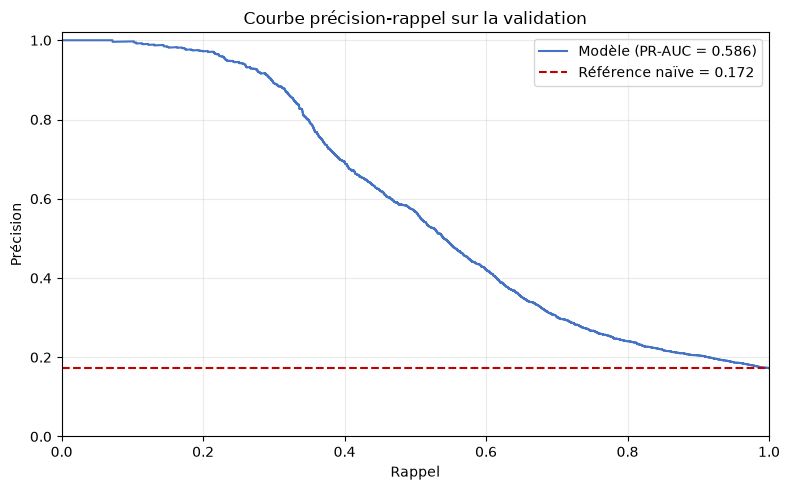

In [6]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

train_pr_auc = average_precision_score(y_train, train_scores)
validation_pr_auc = average_precision_score(y_validation, validation_scores)
train_roc_auc = roc_auc_score(y_train, train_scores)
validation_roc_auc = roc_auc_score(y_validation, validation_scores)
validation_baseline = y_validation.mean()

probability_metric_rows = [
    ['Train', f'{train_pr_auc:.4f}', f'{train_roc_auc:.4f}', f'{y_train.mean():.4f}'],
    ['Validation', f'{validation_pr_auc:.4f}', f'{validation_roc_auc:.4f}', f'{validation_baseline:.4f}'],
]
print(tabulate(
    probability_metric_rows,
    headers=['Jeu', 'PR-AUC', 'ROC-AUC', 'Référence naïve PR-AUC'],
    tablefmt='github',
))
print(f"\nGain de PR-AUC sur la référence de validation : {validation_pr_auc / validation_baseline:.2f} fois.")

validation_precision_curve, validation_recall_curve, validation_thresholds = precision_recall_curve(
    y_validation,
    validation_scores,
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(validation_recall_curve, validation_precision_curve, color='#4472C4', label=f'Modèle (PR-AUC = {validation_pr_auc:.3f})')
ax.axhline(validation_baseline, color='#C00000', linestyle='--', label=f'Référence naïve = {validation_baseline:.3f}')
ax.set_title('Courbe précision-rappel sur la validation')
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : le modèle classe-t-il mieux que le hasard ?

Sur la validation, la PR-AUC vaut **0,5863**, contre une référence naïve de **0,1724**. Le rapport affiché de **3,40** signifie que l'aire obtenue est 3,4 fois plus élevée que le niveau associé à la prévalence. Ce n'est pas « 3,4 fois plus de pannes détectées » : la PR-AUC résume tous les compromis précision-rappel possibles, avant le choix d'un seuil.

La PR-AUC baisse légèrement de **0,6064 sur le train** à **0,5863 sur la validation**, soit environ 0,020 point. Cette baisse est attendue sur des données non utilisées par `fit` et ne révèle pas ici un effondrement manifeste de généralisation. La ROC-AUC de validation vaut **0,7627** : si l'on tire au hasard une panne et une non-panne dans ce jeu, le modèle a environ 76,3 % de chances de donner le score le plus élevé à la panne.

Ces métriques montrent que le classement apporte de l'information. Elles ne donnent encore ni le nombre d'alertes ni le nombre de pannes manquées. Pour cela, il faut transformer les scores en décisions avec un seuil. Voir [ROC-AUC et PR-AUC](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#7-courbes-roc-auc-et-precision-recall).

## Choisir le seuil sur la validation

Le **seuil de décision** transforme une probabilité en classe : une observation est signalée comme panne si son score est supérieur ou égal au seuil. Le seuil `0,5` est une convention, pas nécessairement le meilleur compromis métier.

Pour cette première baseline de maintenance, nous choisissons sur la validation le seuil qui maximise le **score F2**. Le F2 combine précision et rappel en donnant deux fois plus d'importance au rappel. Cette règle réduit l'importance accordée aux fausses alertes par rapport aux pannes manquées. Elle devra être remplacée par une fonction de coût métier lorsque le coût réel d'un faux positif et d'un faux négatif sera connu.

La **matrice de confusion** compte les vrais négatifs, faux positifs, faux négatifs et vrais positifs. La cellule suivante compare le seuil standard `0,5` au seuil F2 retenu, exclusivement sur la validation.

### Traduire un seuil en conséquence opérationnelle

Pour un seuil donné, un **vrai positif** est une panne correctement signalée ; un **faux positif** est une alerte sans panne ; un **faux négatif** est une panne manquée ; un **vrai négatif** est une absence de panne correctement ignorée. Abaisser le seuil augmente généralement le nombre d'alertes : le rappel progresse, mais la précision peut diminuer. Le F2 est la moyenne harmonique pondérée de précision et rappel ; avec `beta=2`, le rappel compte davantage dans le compromis.

La règle appliquée est donc : explorer les seuils **sur validation**, retenir celui qui maximise F2, puis le geler. **À vérifier après la cellule 13 :** comparer les colonnes « Faux positifs » et « Faux négatifs » entre `0,5` et le seuil retenu, puis lire la matrice de confusion de validation. Le seuil final est une hypothèse métier explicite — « une panne manquée est plus coûteuse qu'une fausse alerte » — et non une propriété universelle du modèle.

| Règle           |   Seuil |   Précision |   Rappel |    F1 |    F2 |   Faux positifs |   Faux négatifs |
|-----------------|---------|-------------|----------|-------|-------|-----------------|-----------------|
| Seuil standard  |  0.5    |       0.545 |    0.51  | 0.527 | 0.517 |            1477 |            1700 |
| Seuil F2 retenu |  0.3416 |       0.339 |    0.667 | 0.449 | 0.558 |            4523 |            1157 |

Seuil choisi uniquement sur la validation : 0.3416


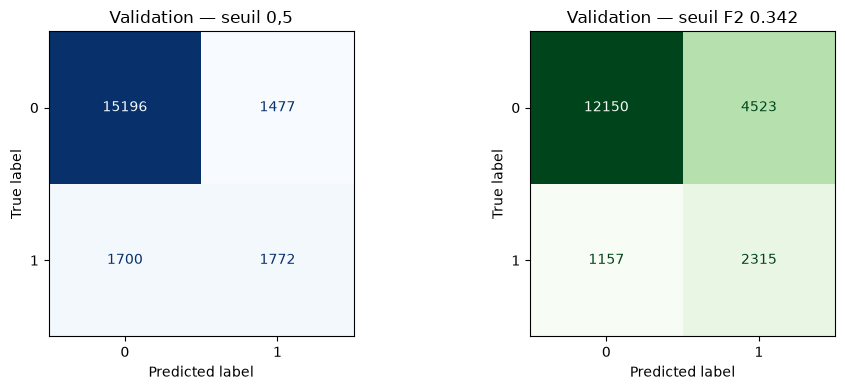

In [7]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)

BETA = 2
curve_precision = validation_precision_curve[:-1]
curve_recall = validation_recall_curve[:-1]
f2_curve = (1 + BETA**2) * curve_precision * curve_recall / (
    BETA**2 * curve_precision + curve_recall + np.finfo(float).eps
)
best_threshold_index = int(np.nanargmax(f2_curve))
selected_threshold = float(validation_thresholds[best_threshold_index])

def metrics_at_threshold(y_true, scores, threshold):
    predictions = (scores >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'threshold': threshold,
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'f2': fbeta_score(y_true, predictions, beta=BETA, zero_division=0),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'predictions': predictions,
    }

validation_default = metrics_at_threshold(y_validation, validation_scores, 0.5)
validation_selected = metrics_at_threshold(y_validation, validation_scores, selected_threshold)

threshold_rows = []
for name, result in [('Seuil standard', validation_default), ('Seuil F2 retenu', validation_selected)]:
    threshold_rows.append([
        name,
        f"{result['threshold']:.4f}",
        f"{result['precision']:.3f}",
        f"{result['recall']:.3f}",
        f"{result['f1']:.3f}",
        f"{result['f2']:.3f}",
        result['fp'],
        result['fn'],
    ])
print(tabulate(
    threshold_rows,
    headers=['Règle', 'Seuil', 'Précision', 'Rappel', 'F1', 'F2', 'Faux positifs', 'Faux négatifs'],
    tablefmt='github',
))
print(f"\nSeuil choisi uniquement sur la validation : {selected_threshold:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_validation, validation_default['predictions'], labels=[0, 1], cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title('Validation — seuil 0,5')
ConfusionMatrixDisplay.from_predictions(
    y_validation, validation_selected['predictions'], labels=[0, 1], cmap='Greens', colorbar=False, ax=axes[1]
)
axes[1].set_title(f'Validation — seuil F2 {selected_threshold:.3f}')
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : quel compromis le seuil F2 produit-il ?

Avec le seuil standard `0,5`, le modèle obtient **54,5 % de précision** et **51,0 % de rappel** sur la validation. Il émet moins de fausses alertes (**1 477 faux positifs**), mais manque **1 700 pannes**. Le seuil `0,5` n'est donc pas neutre : il privilégie ici davantage la précision au détriment de la détection.

En abaissant le seuil à **0,3416**, le rappel monte à **66,7 %** : 543 pannes supplémentaires sont détectées, car les faux négatifs passent de 1 700 à 1 157. La contrepartie est importante : les faux positifs passent de 1 477 à 4 523 et la précision baisse à **33,9 %**. Autrement dit, environ une alerte sur trois correspond réellement à une panne dans la validation.

Le score F2 progresse de **0,517 à 0,558**, ce qui explique le choix automatique du seuil. Cette amélioration n'est défendable que si le métier accepte les 3 046 fausses alertes supplémentaires pour éviter 543 pannes manquées. Le notebook formule cette préférence, mais il ne dispose pas encore des coûts réels permettant de la valider. Voir [scores, probabilités et seuil](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#6-scores-probabilités-et-seuil-de-décision).

## Réaliser l'évaluation finale sur le test

Le jeu de test n'a servi ni à entraîner le pipeline ni à choisir le seuil. Il simule donc une période future restée indépendante des décisions de modélisation.

La cellule suivante applique une seule fois le pipeline et le seuil gelé au test. Elle affiche la PR-AUC, la ROC-AUC, la précision, le rappel, les scores F1/F2 et la matrice de confusion. Une performance proche entre validation et test suggère une stabilité temporelle sur ces deux périodes ; elle ne garantit pas la performance future en production.

### Protocole final : mesurer sans redécider

Le test répond à une seule question : après avoir arrêté le Pipeline et le seuil sur les périodes antérieures, quelle performance observe-t-on sur une période jamais utilisée pour ces choix ? Il est normal que le score du test soit moins bon que celui de validation. En revanche, si le résultat est décevant, on ne modifie ni le seuil ni le modèle à partir du test : on revient à la validation avec une nouvelle hypothèse, puis on réévalue sur un test resté intact.

**À vérifier après la cellule 15 :** la phrase « Seuil gelé depuis la validation » doit afficher exactement le seuil précédemment sélectionné. Lire conjointement PR-AUC, précision, rappel, F1, F2, faux positifs et faux négatifs : aucune métrique isolée ne dit si la solution est exploitable. La courbe et la matrice du test sont le résultat à présenter, avec leurs limites, lors de la soutenance.

Seuil gelé depuis la validation : 0.3416

| Jeu        |   PR-AUC |   ROC-AUC |   Précision |   Rappel |    F1 |    F2 |   Faux positifs |   Faux négatifs |
|------------|----------|-----------|-------------|----------|-------|-------|-----------------|-----------------|
| Validation |    0.586 |     0.763 |       0.339 |    0.667 | 0.449 | 0.558 |            4523 |            1157 |
| Test       |    0.577 |     0.762 |       0.303 |    0.698 | 0.423 | 0.554 |            5573 |            1050 |


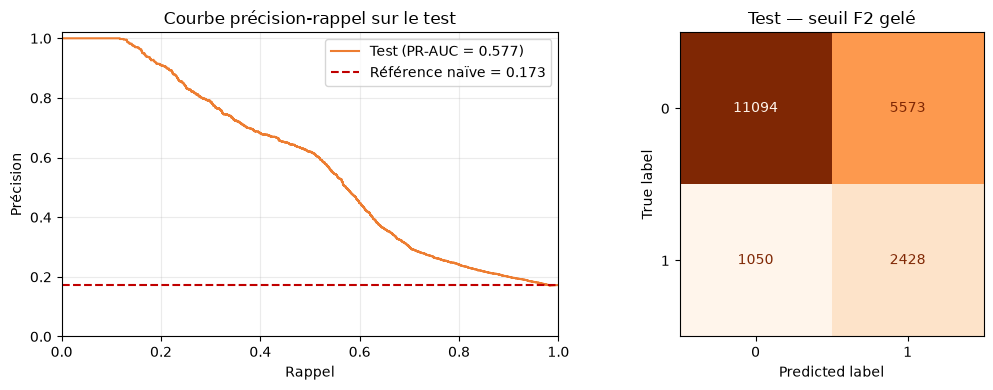

In [8]:
# Le test est consulté après le gel du pipeline et du seuil.
test_scores = model_pipeline.predict_proba(X_test)[:, 1]
test_pr_auc = average_precision_score(y_test, test_scores)
test_roc_auc = roc_auc_score(y_test, test_scores)
test_selected = metrics_at_threshold(y_test, test_scores, selected_threshold)

final_metric_rows = [
    [
        'Validation', validation_pr_auc, validation_roc_auc,
        validation_selected['precision'], validation_selected['recall'],
        validation_selected['f1'], validation_selected['f2'],
        validation_selected['fp'], validation_selected['fn'],
    ],
    [
        'Test', test_pr_auc, test_roc_auc,
        test_selected['precision'], test_selected['recall'],
        test_selected['f1'], test_selected['f2'],
        test_selected['fp'], test_selected['fn'],
    ],
]
formatted_final_rows = [
    [row[0], *[f'{value:.3f}' for value in row[1:7]], row[7], row[8]]
    for row in final_metric_rows
]
print(f'Seuil gelé depuis la validation : {selected_threshold:.4f}\n')
print(tabulate(
    formatted_final_rows,
    headers=['Jeu', 'PR-AUC', 'ROC-AUC', 'Précision', 'Rappel', 'F1', 'F2', 'Faux positifs', 'Faux négatifs'],
    tablefmt='github',
))

test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, test_scores)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(test_recall_curve, test_precision_curve, color='#ED7D31', label=f'Test (PR-AUC = {test_pr_auc:.3f})')
axes[0].axhline(y_test.mean(), color='#C00000', linestyle='--', label=f'Référence naïve = {y_test.mean():.3f}')
axes[0].set_title('Courbe précision-rappel sur le test')
axes[0].set_xlabel('Rappel')
axes[0].set_ylabel('Précision')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.25)
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(
    y_test, test_selected['predictions'], labels=[0, 1], cmap='Oranges', colorbar=False, ax=axes[1]
)
axes[1].set_title('Test — seuil F2 gelé')
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : la performance tient-elle sur le test ?

Le seuil reste bien gelé à **0,3416**. La PR-AUC passe de **0,586 en validation à 0,577 sur le test**, la ROC-AUC reste presque identique (`0,763` contre `0,762`) et F2 passe de `0,558` à `0,554`. Ces écarts faibles suggèrent une performance relativement stable entre ces deux périodes. Ils ne garantissent pas qu'elle restera stable après juin 2026 ou sur d'autres machines.

Sur les **3 478 pannes** du test, le modèle en détecte **2 428** et en manque **1 050**, d'où un rappel de **69,8 %**. Il produit aussi **5 573 fausses alertes** : au total, il déclenche 8 001 alertes, dont seulement 2 428 correspondent à une panne, ce qui explique la précision de **30,3 %**. Une autre lecture utile est donc que près de sept alertes sur dix seraient inutiles si chaque observation positive déclenchait directement une intervention.

Le résultat est meilleur que la référence naïve pour classer les risques, mais il n'établit pas encore la rentabilité opérationnelle. Il faut connaître le coût d'une inspection inutile, celui d'une panne manquée et la capacité des équipes à traiter environ 8 000 alertes sur cette période. Voir [l'application au cas Indusense](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#9-application-au-cas-indusense).

## Interpréter la baseline et conclure

Après standardisation, le signe d'un coefficient de régression logistique indique le sens de l'association avec la probabilité prédite : un coefficient positif augmente le score de panne, un coefficient négatif le diminue, toutes choses égales par ailleurs. La valeur absolue aide à repérer les variables influentes dans ce modèle linéaire.

Un coefficient ne démontre pas une causalité. Les features peuvent être corrélées entre elles, et le dataset peut ne pas représenter les conditions futures de production. De plus, `class_weight='balanced'` modifie l'importance des classes pendant l'apprentissage : les scores servent ici à classer les risques et à appliquer un seuil, mais ne doivent pas être présentés comme des probabilités parfaitement calibrées. Enfin, les snapshots horaires voisins se recouvrent fortement ; le split temporel limite la fuite, sans rendre ces observations indépendantes.

La cellule suivante affiche les coefficients les plus marqués, vérifie les invariants finaux et résume ce que le TP a réellement validé.

### Ce qui peut être affirmé — et ce qui ne le peut pas

Les coefficients standardisés indiquent une **association dans cette baseline** : à variables comparables, leur signe donne le sens dans lequel le score de risque évolue. Ils ne prouvent ni qu'une variable est la cause d'une panne, ni qu'elle restera importante dans un autre modèle ou à une autre période. Le recouvrement des fenêtres horaires signifie aussi que des observations proches restent liées, même si le découpage respecte l'ordre temporel.

**À vérifier après la cellule 17 :** les assertions confirment l'absence des labels et des variables futures parmi les variables explicatives, la validité numérique des scores et une PR-AUC de test supérieure à la référence naïve. Le TP valide une baseline reproductible, une évaluation temporelle et un choix de seuil traçable. Restent à valider avec le métier : les coûts réels des faux positifs et faux négatifs, la capacité à traiter les alertes, la calibration éventuelle des scores et la stabilité en production.

In [9]:
model_coefficients = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_pipeline.named_steps['model'].coef_[0],
})
model_coefficients['valeur_absolue'] = model_coefficients['coefficient'].abs()
top_coefficients = model_coefficients.nlargest(12, 'valeur_absolue').copy()
top_coefficients['sens'] = np.where(
    top_coefficients['coefficient'].ge(0),
    'score de panne en hausse',
    'score de panne en baisse',
)
top_coefficients['coefficient'] = top_coefficients['coefficient'].map(lambda value: f'{value:.4f}')

assert TARGET_COLUMN not in feature_columns
assert not set(label_columns + future_information_columns).intersection(feature_columns)
assert np.isfinite(test_scores).all()
assert 0 < selected_threshold < 1
assert test_pr_auc > y_test.mean(), 'Le modèle ne dépasse pas la référence naïve sur le test.'

print('Variables aux coefficients standardisés les plus marqués :')
print(tabulate(
    top_coefficients[['feature', 'coefficient', 'sens']],
    headers=['Feature', 'Coefficient', 'Association dans le modèle'],
    tablefmt='github',
    showindex=False,
))
print('\nInterprétation prudente : ces coefficients décrivent des associations, pas des causes.')
print(
    f"Le test atteint une PR-AUC de {test_pr_auc:.3f} contre une référence naïve de {y_test.mean():.3f}, "
    f"avec un rappel de {test_selected['recall']:.3f} et une précision de {test_selected['precision']:.3f}."
)
print('\nTP_COMPLET_VALIDE : préparation, déséquilibre, baseline, seuil et test exécutés sans fuite identifiée.')

Variables aux coefficients standardisés les plus marqués :
| Feature                 |   Coefficient | Association dans le modèle   |
|-------------------------|---------------|------------------------------|
| temp_mean_12h           |        1.0485 | score de panne en hausse     |
| voltage_max_24h         |       -0.683  | score de panne en baisse     |
| temp_mean_6h            |       -0.674  | score de panne en baisse     |
| rotation_mean_12h       |       -0.5629 | score de panne en baisse     |
| incident_count_prev_24h |        0.4855 | score de panne en hausse     |
| incident_count_1h       |        0.4584 | score de panne en hausse     |
| voltage_mean_6h         |        0.4505 | score de panne en hausse     |
| voltage_mean_1h         |        0.4432 | score de panne en hausse     |
| voltage_max_1h          |        0.4432 | score de panne en hausse     |
| voltage_mean_24h        |       -0.4288 | score de panne en baisse     |
| pressure_mean_24h       |        0.4166

## Lecture finale : comment interpréter les variables mises en avant ?

`temp_mean_12h` possède le coefficient positif le plus élevé (`+1,0485`) : dans cette régression logistique standardisée, une hausse de cette variable est associée à une hausse du score de panne, toutes les autres variables étant maintenues constantes. À l'inverse, `voltage_max_24h` a un coefficient négatif (`-0,6830`) et est associé à une baisse du score dans les mêmes conditions.

Il ne faut pas interpréter ces signes séparément comme des lois physiques. Plusieurs variables décrivent la même grandeur sur des fenêtres différentes : par exemple, `temp_mean_12h` est positive alors que `temp_mean_6h` est négative. Lorsque des variables sont corrélées, le modèle répartit l'information entre leurs coefficients ; le signe de l'une dépend donc aussi de la présence des autres. Une analyse causale demanderait un protocole différent et des connaissances métier supplémentaires.

## Bilan argumenté du TP

Ce qui est **validé sur les données disponibles** :

- le grain horaire et l'ordre temporel sont contrôlés ;
- les informations futures identifiées sont exclues des variables explicatives ;
- tous les prétraitements et le modèle sont ajustés uniquement sur le train ;
- le seuil `0,3416` est choisi sur la validation, puis gelé ;
- sur le test, la PR-AUC (`0,577`) dépasse la prévalence (`0,173`) et le F2 reste proche de celui de validation ;
- au seuil retenu, le modèle détecte 2 428 pannes sur 3 478, mais produit 5 573 fausses alertes.

Ce qui reste **à valider avant un usage réel** :

- le coût comparé d'une panne manquée et d'une fausse alerte ;
- le nombre d'alertes que les équipes peuvent traiter ;
- la calibration des scores si l'on veut annoncer une probabilité de panne ;
- la stabilité sur de nouvelles périodes, d'autres machines et en production ;
- l'absence d'autres formes de fuite non visibles dans les seuls noms de colonnes.

### Formulation possible à l'oral

> J'ai construit une baseline de classification binaire pour prédire une panne dans les 24 heures. J'ai conservé un découpage chronologique, ajusté le Pipeline uniquement sur le train et choisi le seuil sur la validation avec F2, car l'hypothèse métier privilégie le rappel. Sur le test, le modèle classe mieux les risques qu'une référence naïve et détecte 69,8 % des pannes, mais sa précision de 30,3 % entraîne beaucoup de fausses alertes. Le modèle est donc pédagogiquement validé comme baseline, pas encore comme solution de production.

Pour réviser cette argumentation, consulter [la fiche Classification binaire et découpage temporel](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md#points-à-savoir-expliquer-lors-de-la-soutenance) et [le cours structuré sur l'évaluation](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#10-révisions-qcm-et-soutenance).